# CS156: Pipeline - First Draft

**Do I sound like AI, or have I always been a bad writer?**  

With the amount of AI we use on a day to day, I am fairly sure that a lot of the content I consume, whether it be the news, social media, or even the PCW that I grade, might be AI-assisted, if not completely AI-generated. This makes me wonder: as a symptom of consuming so much 'slop,' could my own writing also be showing traits commonly attributed to AI-generated text, such as structural uniformity, reduced variance in sentence length, or particular lexical patterns? (Wikepedia, n.d.-a)

This report answers this question by first training a model to classify assignments I wrote pre-Fall 2024, before AI tools had become sufficiently capable and convenient to function as routine academic aids, from later submissions. If the model can reliably distinguish between the two periods, this suggests measurable stylistic differences. I then examine which features drive this separation and analyze whether those differences align with documented stylistic characteristics often associated with AI-generated writing.

## The Data

To create the dataset to be used in this pipeline, I retrieved past written assignments from my Minerva email's Google Drive using a Colab notebook ([GitHub](https://colab.research.google.com/drive/1f_YmZ3cR82UPcLH7uNJ9DUu-x7Gllc7c#scrollTo=e160UdxwwBmt)), and manually labelled the documents I wanted to include.

Importantly, since the focus of the models trained here is stylistic drift in *my* writing, I excluded the following assignment categories: 
- **Skill builders from CS111 and CS113:** Mostly math and instructions, not much original prose. Also hand-written, which adds processing complexity.
- **Group assignments:** Written by multiple people, so I limited the dataset to me.
- **Heavily templated assignments:** Workbooks and worksheets with instructions included dilute my own voice. This excluded several FA50/FA51, Deep Dives from CS111/CS113, problem sets from CS114, and some SS110/SS152 assignments formatted as cover sheets.

I did include non-essay documents that reflect my own writing: video scripts and reflection documents from technical interviews.

Based on these criteria, 54 documents qualified. However, 4 were from outside Google Drive (PDFs from OverLeaf or exported jupyter notebooks), so I excluded them to keep data processing consistent. That left 51 documents in the final dataset.

## Loading the Data

The scraped data is stored in a CSV file with UTF-8 encoding, which I chose to preserve punctuation like em-dashes and curly quotes that might carry stylistic signal.

In [31]:
# Install necessary packages
!pip install pandas numpy scikit-learn matplotlib seaborn scipy textstat nltk spacy wordcloud
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 kB 6.4 MB/s eta 0:00:00

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 21.1 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import spacy

# Sklearn imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

# Stylometric analysis
import textstat
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/suiseinakagawa/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [20]:
# Loading dataset

df = pd.read_csv("gdrive_scraped_data.csv", encoding='utf-8') 


## Pre-processing and EDA

While I am most interested in stylistic drift, I first train a baseline classifier (WHICH) to see whether there is any meaningful difference between my pre-AI (pre-Fall 2024) and post-AI (Fall 2024 and later) writing.

This section describes the exact cleaning steps used in the code and the assumptions behind them.

### Data Cleaning to Prevent Leakage and Labeling

To ensure the classifier learns stylistic patterns rather than metadata, I wanted to train it on cleaned data where elements or sections that may cause leakage are removed. In order to compare model performance across data with different levels of cleaning to verify the model is truly learning from the main text, I created a fixed cleaning pipeline: `remove_cover_sheet` -> `remove_toc` -> `extract_body_only` -> `remove_hc_tags`.

- `text_raw`: Original text with all content. This is pulled directly from the source csv file. 
- `text_clean`: Fully cleaned. This removes the cover sheet, TOC, References, Appendices, and HC/LO tags, which can cause leakage from course/topic/time. I also removed AI Statements because the wording, tool names, and format may shift over time or by course. This is justified as the goal is to capture main-body prose, not these sections, that are less stylistic and more structural. 

I still use an intermediate `no_cover` step inside the pipeline (cover sheet + TOC removed), because the heuristics build on each other, but I decided not to keep it as a permanent column in the final dataframe.

In addition to cleaning, I added the following metadata columns: 
- `course_code`: Extracted from the cover sheet using a 2-letter + 2-3 digit regex. 
- `label`: The label for model training. Pre-AI (pre-Fall 2024) work is represented by 0 and post-AI (Fall 2024 or later) work is represented by 1. This labeling scheme reflects the real-world timeline of when AI tools became standard in my academic toolkit.

Importantly, each cleaning step makes some key assumptions about my data, which I verified as I implemented the code: 

- **Cover sheets or headers exist at the start of the document.** The cover sheet is assumed to appear in the first 500-3000 characters and to contain either a Minerva header, a horizontal rule, a large page break, or a course code. This lets the heuristic remove only the top portion.
- **TOCs are near the top and look like lists with page numbers.** The TOC removal checks the first ~20 lines for multiple lines ending in digits or an explicit "Contents" header.
- **End-matter starts at explicit markers.** The body is truncated at the earliest of: References/Bibliography, Appendix/Appendices, Word Count, or AI Statement/AI Use headings, but only if they appear after 100+ characters.
- **HC/LO tags are structured as #tag: blocks.** The cleaning assumes these are metadata blocks that can be removed without losing core prose.

This setup lets me compare model performance on raw text vs. main-body prose to check whether the model is learning writing style rather than metadata.


In [21]:
# Preprocessing functions

VALID_COURSES = ['CP192', 'CS146', 'GL96', 'CS156', 'SS111',
                 'CP191', 'CS166', 'GL95', 'SS152', 'SS156', 
                 'CS113', 'CS114', 'GL94', 'SS110', 
                 'CS110', 'CS111', 'GL93', 'SS112', 
                 'CX51', 'EA51', 'FA51', 'GL92', 'MC51', 
                 'CX50', 'EA50', 'FA50', 'GL91', 'MC50', 'IL199']

def extract_course_code(text):
    """
    Extract course code from cover sheet (e.g., CS110, GL96).
    
    Searches first 500 chars for 2-letter prefix + 2-3 digit number.
    Returns: course_code or None if not found
    """
    pattern = r'\b([A-Z]{2})[\s-]?(\d{2,3})\b'
    matches = re.findall(pattern, text[:500])
    
    if matches:
        prefix, number = matches[0]
        return f"{prefix}{number}"
    
    return None

def remove_cover_sheet(text):
    """
    Remove cover sheet content using layered heuristics.
    
    Strategies (applied in order):
    1) Minerva-specific: Searches for horizontal rules or TOC header in first 3000 chars
    2) Major page break: 6+ consecutive blank lines
    3) Early horizontal rule: 5+ underscores in first 2000 chars
    4) Course code fallback: Skips 2 lines after finding course code
    """
    text = text.replace('\r\n', '\n')

    if 'Minerva University' in text[:500]:
        early_section = text[:3000]
        rule_match = re.search(r'\n\s*_{5,}\s*\n', early_section)
        toc_match = re.search(r'(?i)\n\s*(table of )?contents\s*\n', early_section)
        candidates = []
        if rule_match:
            candidates.append(('rule', rule_match.start(), rule_match.end()))
        if toc_match:
            candidates.append(('toc', toc_match.start(), toc_match.end()))
        if candidates:
            kind, start, end = min(candidates, key=lambda x: x[1])
            return text[start:] if kind == 'toc' else text[end:]

    page_break_pattern = r'(\n\s*){6,}'
    match = re.search(page_break_pattern, text)
    if match:
        return text[match.end():]

    horizontal_rule_pattern = r'\n\s*_{5,}\s*\n'
    match = re.search(horizontal_rule_pattern, text[:2000])
    if match:
        return text[match.end():]

    course_code_pattern = r'\b([A-Z]{2})[\s-]?(\d{2,3})\b'
    match = re.search(course_code_pattern, text[:500])
    if match:
        pos = match.end()
        for _ in range(2):
            next_newline = text.find('\n', pos)
            if next_newline == -1:
                break
            pos = next_newline + 1
        return text[pos:]

    return text

def remove_hc_tags(text):
    """
    Remove HC tags (#tag: explanation) and standalone horizontal rules.
    
    Removes:
    - HC tag blocks: #tag: explanation (continues until blank line)
    - Horizontal rules: Lines with 5+ underscores
    """
    text = re.sub(r'\#[A-Za-z0-9\-]+:[^\n]*(?:\n(?!\n)[^\n]*)*', '', text)
    text = re.sub(r'^\s*_{5,}\s*$', '', text, flags=re.MULTILINE)
    return text

def remove_toc(text):
    """
    Remove table of contents blocks using two strategies.
    
    Strategy 1 - Explicit header: Matches "Table of Contents" or "Contents" header.
                 Ends at double newline or horizontal rule.
    Strategy 2 - Page number heuristic: Detects 3+ lines ending with digits in first 20 lines.
                 Removes up to first double blank line, or first blank line as fallback.
    """
    text = text.replace('\r\n', '\n')

    toc_pattern = r'(?i)(table of )?contents\s*\n'
    match = re.search(toc_pattern, text)
    if match:
        toc_start = match.start()
        remaining = text[match.end():]
        end_match = re.search(r'\n\s*\n|\n\s*_{5,}\s*\n', remaining)
        if end_match:
            return text[:toc_start] + remaining[end_match.end():].lstrip()
        return text[:toc_start]

    lines = text.split('\n')
    sample = lines[:20]
    toc_like = [ln for ln in sample if re.search(r'\s+\d+\s*$', ln)]
    if len(toc_like) >= 3:
        for i in range(len(sample) - 1):
            if sample[i].strip() == '' and sample[i + 1].strip() == '':
                return '\n'.join(lines[i + 1:]).lstrip()
        for i in range(len(sample)):
            if sample[i].strip() == '':
                return '\n'.join(lines[i + 1:]).lstrip()

    return text

def extract_body_only(text):
    """
    Extract main body text by cutting at the earliest end-of-body marker.
    
    Detects: References, Bibliography, Appendix, Appendices, Word Count, AI Statement variants.
    Protection: Only cuts if marker appears after 100+ chars (prevents removing entire document).
    """
    text = text.replace('\r\n', '\n')
    
    end_markers = [
        r'(?i)^(references|bibliography)',
        r'(?i)^(appendix|appendices)',
        r'(?i)^(word count|ai statement|ai use|statement on ai)',
    ]
    
    earliest_match = None
    earliest_pos = len(text)
    
    for pattern in end_markers:
        match = re.search(pattern, text, re.MULTILINE)
        if match and match.start() > 100 and match.start() < earliest_pos:
            earliest_pos = match.start()
            earliest_match = match
    
    if earliest_match:
        return text[:earliest_match.start()].strip()
    
    return text.strip()


def preprocess_dataframe(df):
    """
    Apply all preprocessing steps to create cleaned text columns.
    
    Columns created:
    - text_raw: Original text (baseline)
    - text_clean: Body text only (no coversheet, TOC, references, appendix, AI statements, HC tags)
    - course_code: Extracted course code
    - label: 0 = pre-AI courses, 1 = post-AI courses
    """
    df_processed = df.copy()
    df_processed['course_code'] = df_processed['text_raw'].apply(extract_course_code)
    df_processed['no_cover'] = df_processed['text_raw'].apply(remove_cover_sheet).apply(remove_toc)
    df_processed['text_clean'] = df_processed['no_cover'].apply(extract_body_only).apply(remove_hc_tags)
    PRE_AI_COURSES = ['CX51', 'EA51', 'FA51', 'GL92', 'MC51', 
                      'CX50', 'EA50', 'FA50', 'GL91', 'MC50', 'IL199']
    df_processed['label'] = df_processed['course_code'].apply(
        lambda x: 0 if x in PRE_AI_COURSES else 1
    )
    
    return df_processed

# Apply preprocessing and keep relevant columns
df_processed = preprocess_dataframe(df)
df_processed = df_processed[['name', 'course_code', 'label', 'text_raw', 'text_clean']]

print("Preprocessing complete.")
print(f"Total documents: {len(df_processed)}")

# Display summary table with truncated text for readability
display_df = df_processed.head().copy()
text_cols = ['text_raw', 'text_clean']
for col in text_cols:
    display_df[col] = display_df[col].apply(lambda x: (x[:75] + '...') if isinstance(x, str) and len(x) > 75 else x)
display(display_df[['course_code', 'name', 'label'] + text_cols])

Preprocessing complete.
Total documents: 50


,course_code,name,label,text_raw,text_clean
0,CP192,Reflection on Track Options [final],1,﻿Reflection on Track Options\r\n\r\n\r\n\r\n\r...,Reflection on Track Options\nProcess Documenta...
1,SS111,LBA [final],1,﻿LBA: Analyzing the Bangle Market of Charminar...,LBA: Analyzing the Bangle Market of Charminar\...
2,GL96,Elevation Reflection & Engagement [final],1,﻿Elevation Reflection & Engagement \r\nGL96\r\...,One way I plan to engage meaningfully with Hyd...
3,GL96,Ethnographic Assignment [final],1,﻿Ethnographic Assignment\r\n\r\n\r\n\r\n\r\nMi...,Ethnographic Assignment\nIntroduction\nFor thi...
4,SS156,Final assignment [final],1,﻿Tab 1\r\n\r\n\r\n\r\n\r\n\r\n\r\nComparative ...,Comparative Analysis of Political Systems: Fur...


In [5]:
# # Manual inspection of all documents
# # Commented out to reduce bulk

# pd.set_option('display.max_colwidth', None)

# for idx, row in df_processed.iterrows():
#     print(f"\n{'='*100}")
#     print(f"📄 Document #{idx + 1}: {row['name']}")
#     print(f"   Course: {row['course_code']} | Label: {row['label']} ({'pre-AI' if row['label'] == 0 else 'post-AI'})")
#     print(f"{'='*100}")
        
#     print(f"\n[TEXT_CLEAN - First 100 chars]")
#     print(row['text_clean'][:100] if isinstance(row['text_clean'], str) else row['text_clean'])
#     print(f"\n[TEXT_CLEAN - Last 100 chars]")
#     print(row['text_clean'][-100:] if isinstance(row['text_clean'], str) else row['text_clean'])

### Text Normalization and Tokenization

In addition to separating main text from structural artefacts, I standardize case and whitespace to reduce surface-level variation (e.g., casing and uneven spacing) before tokenization using spaCy. I chose spaCy over a simple regex-based tokenizer because this analysis depends on consistent sentence boundaries and stable token definitions. Naive regex rules tend to break on abbreviations, decimal numbers, ellipses, and formatting irregularities, which would directly distort structural metrics of interest like mean sentence length and variance. 

I disable part-of-speech tagging, dependency parsing, named entity recognition, and lemmatization to keep the pipeline lightweight and deterministic. In particular, lemmatization would collapse inflected word forms and remove variation that may itself be stylistically meaningful.

This step produces three representations per document: a list of tokens (including punctuation), a word list excluding whitespace, and a list of sentence strings. These structured outputs form the basis for feature engineering and exploratory analysis. 

Upon tokenization, I split raw vs. clean text into separate dataframes so the core metadata stays small and I can compare feature sets cleanly without carrying around extra columns. That also makes it easy to swap in either raw or clean inputs for each model.


In [22]:
# Normalization 

def normalize_text(text):
    """Lowercase and collapse whitespace for consistent tokenization."""
    if not isinstance(text, str):
        return text
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Create a normalized column from the raw and cleaned text
df_processed["text_raw_norm"] = df_processed["text_raw"].apply(normalize_text)
df_processed["text_clean_norm"] = df_processed["text_clean"].apply(normalize_text)

print("Normalization complete.")

# Display summary table with truncated text for readability
display_df = df_processed.head().copy()
text_cols = ['name', 'text_raw_norm', 'text_clean_norm']
for col in text_cols:
    display_df[col] = display_df[col].apply(lambda x: (x[:75] + '...') if isinstance(x, str) and len(x) > 75 else x)
display(display_df[['course_code', 'name', 'label'] + text_cols])


Normalization complete.


,course_code,name,label,name,text_raw_norm,text_clean_norm
0,CP192,Reflection on Track Options [final],1,Reflection on Track Options [final],﻿reflection on track options minerva universit...,reflection on track options process documentat...
1,SS111,LBA [final],1,LBA [final],﻿lba: analyzing the bangle market of charminar...,lba: analyzing the bangle market of charminar ...
2,GL96,Elevation Reflection & Engagement [final],1,Elevation Reflection & Engagement [final],﻿elevation reflection & engagement gl96 suisei...,one way i plan to engage meaningfully with hyd...
3,GL96,Ethnographic Assignment [final],1,Ethnographic Assignment [final],﻿ethnographic assignment minerva university gl...,ethnographic assignment introduction for this ...
4,SS156,Final assignment [final],1,Final assignment [final],﻿tab 1 comparative analysis of political syste...,comparative analysis of political systems: fur...


In [23]:
# SpaCy tokenizer

nlp = spacy.load("en_core_web_sm", disable=["ner", "tagger", "parser", "lemmatizer"])
nlp.add_pipe("sentencizer")

def spacy_tokenize(text):
    """
    Tokenize text with spaCy.

    Returns a dict with:
    - tokens: all tokens including punctuation
    - words: tokens excluding spaces
    - sentences: list of sentence strings
    """
    if not isinstance(text, str):
        return {"tokens": [], "words": [], "sentences": []}

    doc = nlp(text)
    tokens = [token.text for token in doc]
    words = [token.text for token in doc if not token.is_space]
    sentences = [sent.text.strip() for sent in doc.sents]

    return {"tokens": tokens, "words": words, "sentences": sentences}

# Keep tokenized outputs separate to avoid bloating the main dataframe
base_cols = ["name", "course_code", "label"]

df_tokens_raw = df_processed[base_cols + ["text_raw_norm"]].copy()
df_tokens_clean = df_processed[base_cols + ["text_clean_norm"]].copy()

df_tokens_raw["token_data"] = df_tokens_raw["text_raw_norm"].apply(spacy_tokenize)
df_tokens_clean["token_data"] = df_tokens_clean["text_clean_norm"].apply(spacy_tokenize)

print("Tokenization complete. Token outputs saved to df_tokens_raw and df_tokens_clean.")

Tokenization complete. Token outputs saved to df_tokens_raw and df_tokens_clean.


### Feature Engineering

To train my models to recognize AI-like writing (Wikipedia, n.d.-b), I decided to engineer the following features commonly used in authorship analysis (Hastewire, 2025-a; Hastewire, 2025-b): 

* Structural
    * Mean sentence length (words per sentence): AI-generated text tends to be comprised of long sentences with complex structure. 
    * Sentence length variability (standard deviation): Not only does AI text tend to be long-winded, it is *consistently* long, with lower variance in sentence length than human-produced writing. 

* Lexical
    * Lexical diversity (unique words / total words): AI (specifically, LLMs) are probabilistic models, and tend to 'regress towards the mean' 

* Punctuation (count per total tokens)
    * Comma rate: Clause density, like sentence length, is more varied in human writing compared to uniformly complex AI prose. 
    * Semicolon rate: Semicolons are frequent in formal published text (books, academic writing) where LLMs extract most of their training signal. 
    * Colon rate: Colons introduce explanations, lists, definitions, and other structured chunks of information, which could be more common in AI training data.  
    * Dash rate: LLMs overuse em-dashes; this is a well-documented AI hallmark. 

* Function words (count per total words): The use of function words is often unconscious and thus a good indicator of personal style, and their use if often consisten across subject matter. Here I chose to encode the relative frequency of the 5 most commonly used function words based on the  Oxford English Corpus (OEC) (Wikipedia, n.d.-b). 
    * the
    * to
    * of
    * and
    * a/an (counted together as a single feature, since they're functionally equivalent)

In [37]:
# Feature Engineering

def compute_features(df_tokens):
    """
    Compute 12 stylometric features from tokenized data.
    
    Features:
    1-2: Mean sentence length (words/sentence), sentence length variability (std dev of sentence lengths)
    3: Lexical diversity (unique words / total words)
    4-7: Punctuation rates per token: comma, semicolon, colon, dash (punctuation count / total tokens)
    8-12: Function word frequencies per word: the, to, of, and, a/an (word count / total words)
    """
    features = []
    
    for idx, row in df_tokens.iterrows():
        token_dict = row["token_data"]
        words = token_dict["words"]
        tokens = token_dict["tokens"]
        sentences = token_dict["sentences"]
        
        feat_dict = {"name": row["name"], "course_code": row["course_code"], "label": row["label"]}
        
        # 1. Mean sentence length
        if sentences:
            sent_lengths = [len(s.split()) for s in sentences]
            feat_dict["mean_sent_len"] = np.mean(sent_lengths)
        else:
            feat_dict["mean_sent_len"] = 0
        
        # 2. Sentence length variability (std dev)
        if len(sentences) > 1:
            feat_dict["sent_len_var"] = np.std(sent_lengths)
        else:
            feat_dict["sent_len_var"] = 0
        
        # 3. Lexical diversity
        total_words = len(words)
        unique_words = len(set(words))
        feat_dict["lex_diversity"] = unique_words / total_words if total_words > 0 else 0
        
        # 4-7. Punctuation rates
        total_tokens = len(tokens)
        feat_dict["comma_rate"] = tokens.count(",") / total_tokens if total_tokens > 0 else 0
        feat_dict["semicolon_rate"] = tokens.count(";") / total_tokens if total_tokens > 0 else 0
        feat_dict["colon_rate"] = tokens.count(":") / total_tokens if total_tokens > 0 else 0
        feat_dict["dash_rate"] = (tokens.count("-") + tokens.count("–") + tokens.count("—")) / total_tokens if total_tokens > 0 else 0
        
        # 8-12. Function word frequencies
        function_words = {"the", "to", "of", "and"}
        words_lower = [w.lower() for w in words]
        for fw in function_words:
            feat_dict[f"freq_{fw}"] = words_lower.count(fw) / total_words if total_words > 0 else 0
        
        # Special handling for a/an (count both as single feature)
        a_an_count = words_lower.count("a") + words_lower.count("an")
        feat_dict["freq_a"] = a_an_count / total_words if total_words > 0 else 0
        
        features.append(feat_dict)
    
    return pd.DataFrame(features)

# Compute features for both raw and clean datasets
X_raw_df = compute_features(df_tokens_raw)
X_clean_df = compute_features(df_tokens_clean)

print("Feature engineering complete.")
print(f"\nX_raw shape: {X_raw_df.shape}")
print(f"X_clean shape: {X_clean_df.shape}")
print(f"\nX_raw columns: {list(X_raw_df.columns)}")
print(f"\nX_raw sample:\n{X_raw_df.head()}")

Feature engineering complete.

X_raw shape: (50, 15)
X_clean shape: (50, 15)

X_raw columns: ['name', 'course_code', 'label', 'mean_sent_len', 'sent_len_var', 'lex_diversity', 'comma_rate', 'semicolon_rate', 'colon_rate', 'dash_rate', 'freq_to', 'freq_of', 'freq_the', 'freq_and', 'freq_a']

X_raw sample:
                                        name course_code  label  \
0        Reflection on Track Options [final]       CP192      1   
1                                LBA [final]       SS111      1   
2  Elevation Reflection & Engagement [final]        GL96      1   
3            Ethnographic Assignment [final]        GL96      1   
4                   Final assignment [final]       SS156      1   

   mean_sent_len  sent_len_var  lex_diversity  comma_rate  semicolon_rate  \
0      27.934783     13.295802       0.267488    0.054630        0.000333   
1      22.695652     12.882191       0.324761    0.063924        0.002939   
2      26.444444      7.529366       0.643939    0.049242   

### EDA 

I conducted some exploratory data analysis of my samples based on the features above in addition to the tokenized text. 

First, I verify that the classes are well-balanced enough for model training. 

In [52]:
# Class balance check

class_counts = X_clean_df['label'].value_counts().sort_index()
total_docs = len(X_clean_df)

print("Class Balance:")
print(f"  Pre-AI (0): {class_counts[0]} documents ({class_counts[0]/total_docs*100:.1f}%)")
print(f"  Post-AI (1): {class_counts[1]} documents ({class_counts[1]/total_docs*100:.1f}%)")
print(f"  Total: {total_docs} documents")

Class Balance:
  Pre-AI (0): 22 documents (44.0%)
  Post-AI (1): 28 documents (56.0%)
  Total: 50 documents


The wordclouds below show the common terms in raw (top row) vs cleaned (bottom row) text, separated by their label (left: pre-AI, right: post-AI). The minimal top vs bottom difference shows that stripping formatting, such as coversheets, AI Statements, references, and appendices, does not have much effect on common vocabulary, which alighs with expectations as these sections often contribute unique elements such as reference titles and names to the documents. 

Comparing the left vs right columns, it can be seen that the commonly found nouns differ significantly. This highlights a key limitation of this data: labels are time-correlated, which also makes them course-dependent. Thus, as the subject matter differs significantly across classes, we should not use content directly in classification. 

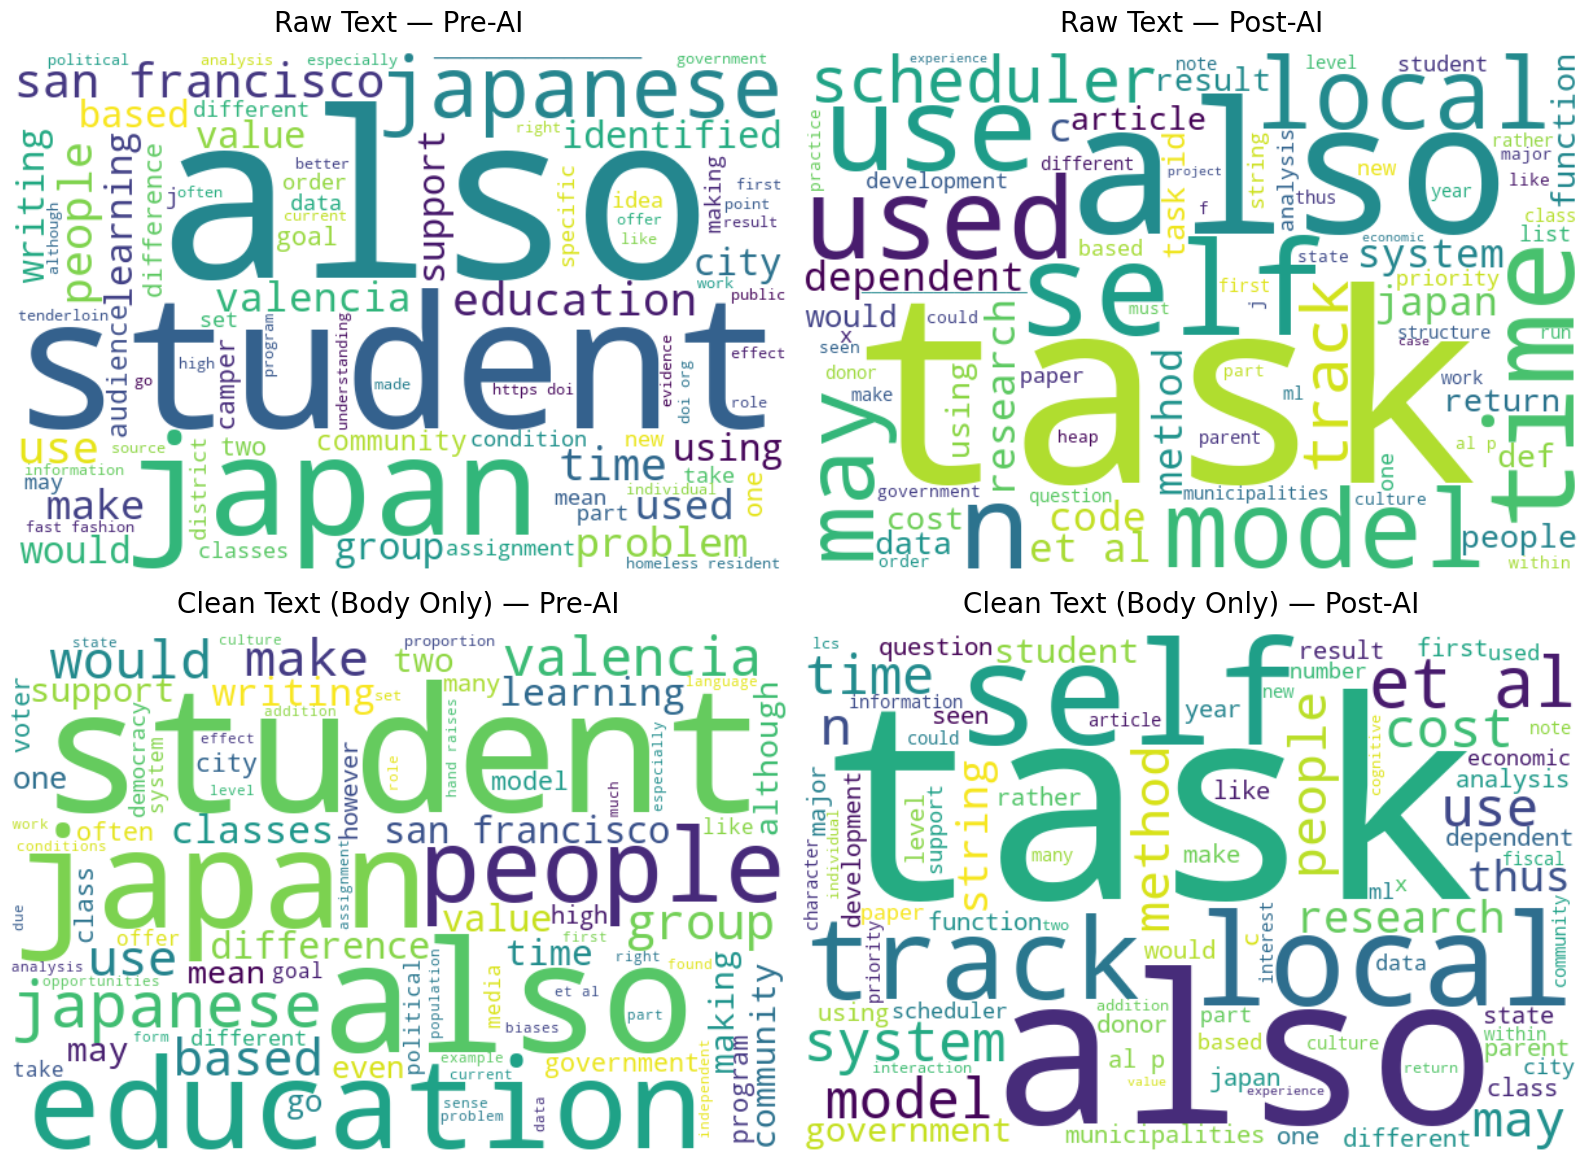

In [ ]:
# Wordcloud to visualize subject matter and content

# Generic English stopwords 
stop_words = set(stopwords.words('english'))
# Remove APA/structural noise 
stop_words.update(['figure', 'table'])  

fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # increased height for padding

text_sources = [
    ('text_raw_norm', 'Raw Text'),
    ('text_clean_norm', 'Clean Text (Body Only)')
]

labels_to_plot = [0, 1]
label_names = ['Pre-AI', 'Post-AI']

for row, (text_col, text_label) in enumerate(text_sources):
    for col, (label, label_name) in enumerate(zip(labels_to_plot, label_names)):
        ax = axes[row, col]
        
        combined_text = ' '.join(
            df_processed[df_processed['label'] == label][text_col].astype(str).tolist()
        )
        
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap='viridis',
            max_words=80,
            relative_scaling=0.5,
            min_font_size=10,
            stopwords=stop_words
        ).generate(combined_text)
        
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{text_label} — {label_name}', fontsize=20, pad=15)

plt.tight_layout()
plt.show()

The histograms below show how the engineered features differ across classes. All show significant overlap, suggesting that no single feature is sufficient to reliably distinguish the classes. 

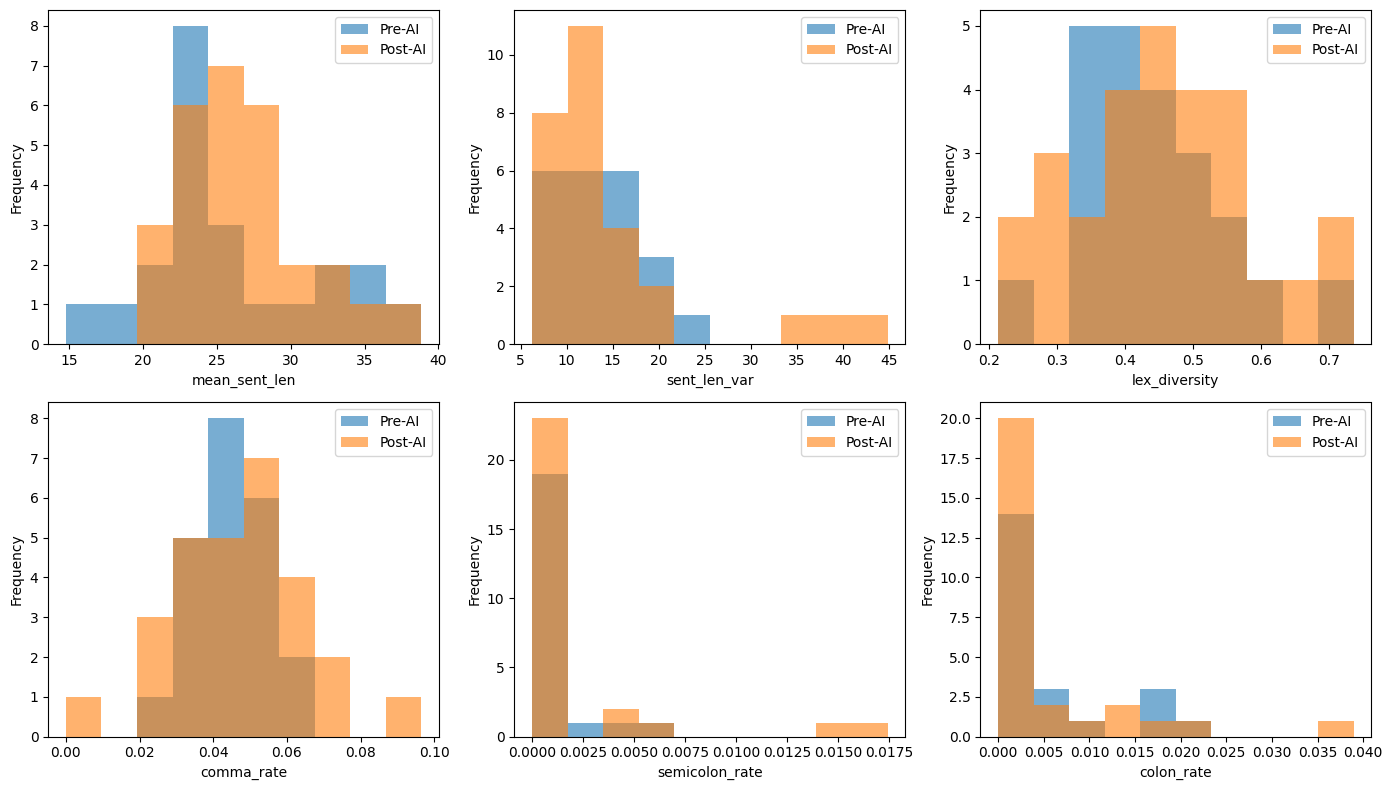

In [ ]:
# Stylometric feature distributions

# Stylometric feature distributions

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features_to_plot = ['mean_sent_len', 'sent_len_var', 'lex_diversity', 'comma_rate', 'semicolon_rate', 'colon_rate']

for ax, feat in zip(axes.flat, features_to_plot):
    # Get the range of the feature across both groups
    min_val = X_clean_df[feat].min()
    max_val = X_clean_df[feat].max()
    bins = np.linspace(min_val, max_val, 11)  # 10 bins
    
    ax.hist(X_clean_df[X_clean_df['label']==0][feat], bins=bins, alpha=0.6, label='Pre-AI')
    ax.hist(X_clean_df[X_clean_df['label']==1][feat], bins=bins, alpha=0.6, label='Post-AI')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

The heapmap below shows pair-wise feature correlations. Most feature pair show none to weak correlations. 

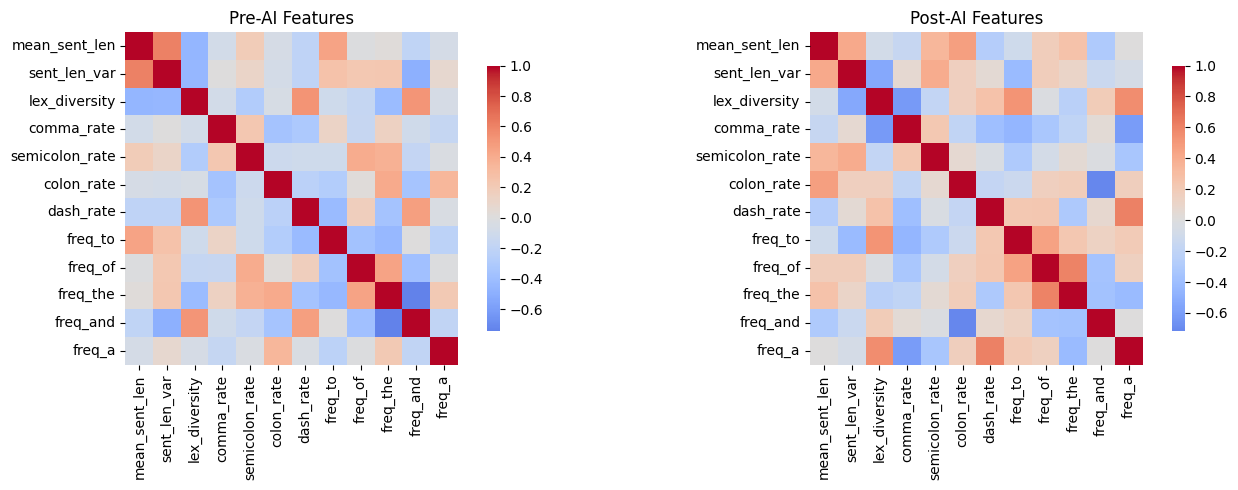

In [41]:
# Heatmap of feature correlations by label 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, label in enumerate([0, 1]):
    subset = X_clean_df[X_clean_df['label']==label].drop(['name', 'course_code', 'label'], axis=1)
    corr = subset.corr()
    sns.heatmap(corr, ax=axes[idx], cmap='coolwarm', center=0, square=True, 
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f"{'Pre-AI' if label==0 else 'Post-AI'} Features")

plt.tight_layout()
plt.show()

While lexical diversity within individual documents is useful, I was also curious whether my writing has regressed toward common English words—a documented characteristic of LLM output. Since LLMs are probabilistic models trained on large text corpora, they tend to favor high-frequency words and avoid uncommon vocabulary.

To test this, I computed a corpus-relative diversity metric using the top 1000 most common words from the NLTK Brown Corpus as a baseline (I chose this corpus for easy access via NLTK). The Brown Corpus is a 1 million-word collection of texts from diverse genres and serves as a standard linguistic reference for American English. I then measured what proportion of words in each document fell within this established frequency list.

Based on the violin plots, my pre-AI assignments tend to use fewer common words overall, whereas my post-AI work shows greater variability: some use over 70% common vocabulary, while others maintain more specialized vocabulary.


In [50]:
# Exploratory: Corpus-relative diversity (regression to common words)

# Download NLTK Brown Corpus if not available and extract top 1000 most common words
try:
    nltk.data.find('corpora/brown')
except LookupError:
    nltk.download('brown')

from nltk.corpus import brown
word_freq = nltk.FreqDist(w.lower() for w in brown.words() if w.isalpha())
TOP_1000_WORDS = set(word for word, freq in word_freq.most_common(1000))

print(f"Loaded top 1000 words from Brown Corpus. Total corpus words: {len(word_freq)}")

def compute_corpus_relative_diversity(df_tokens):
    """
    Compute corpus-relative metrics (exploratory, not main features).
    
    Measures: % of words that fall in top 1000 most common English words (from Brown Corpus).
    High % = regressing to mean (AI-like behavior)
    Low % = maintaining quirky/unique vocabulary
    """
    results = []
    
    for idx, row in df_tokens.iterrows():
        token_dict = row["token_data"]
        words = token_dict["words"]
        
        words_lower = [w.lower() for w in words]
        total_words = len(words_lower)
        
        common_count = sum(1 for w in words_lower if w in TOP_1000_WORDS)
        common_ratio = common_count / total_words if total_words > 0 else 0
        
        results.append({
            "name": row["name"],
            "label": row["label"],
            "common_word_ratio": common_ratio,
            "unique_words_count": len(set(words_lower))
        })
    
    return pd.DataFrame(results)

# Compute corpus-relative metrics for exploration
corpus_rel_raw = compute_corpus_relative_diversity(df_tokens_raw)
corpus_rel_clean = compute_corpus_relative_diversity(df_tokens_clean)

print("Corpus-relative diversity computed.")


Loaded top 1000 words from Brown Corpus. Total corpus words: 40234
Corpus-relative diversity computed.


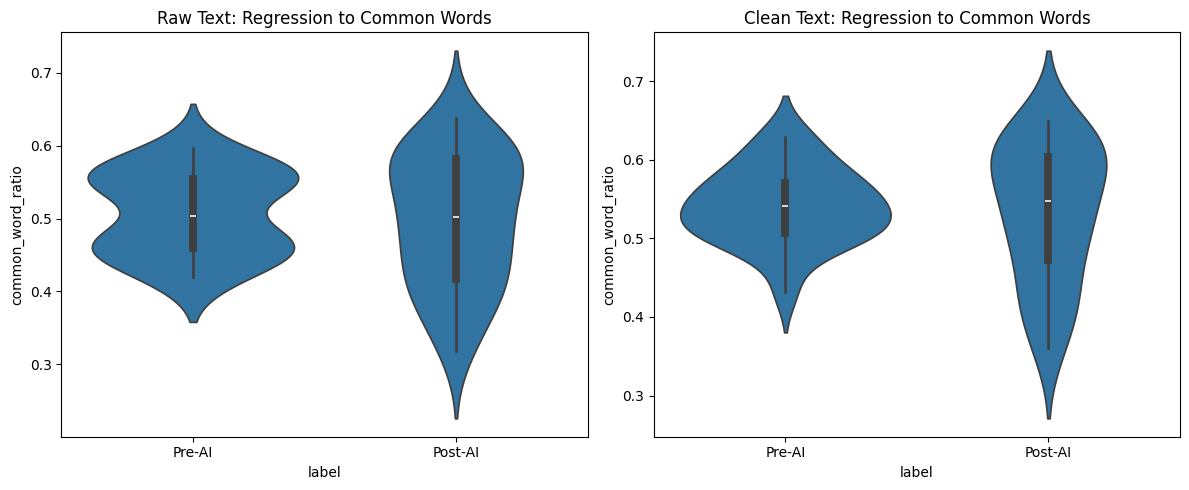

In [51]:
# Common word ratio distributions

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=corpus_rel_raw, x='label', y='common_word_ratio', ax=axes[0])
axes[0].set_title('Raw Text: Regression to Common Words')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Pre-AI', 'Post-AI'])

sns.violinplot(data=corpus_rel_clean, x='label', y='common_word_ratio', ax=axes[1])
axes[1].set_title('Clean Text: Regression to Common Words')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Pre-AI', 'Post-AI'])

plt.tight_layout()
plt.show()

## Analysis

## Model Selection 

## Training 

In [8]:
# #@title also session 5 PCW (CHANGE LATER)

# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn import metrics, naive_bayes

# labels, texts = df['v1'], df['v2']
# vectorizer = text.TfidfVectorizer()
# vec_texts = vectorizer.fit_transform(texts)


# # We train a model
# model = naive_bayes.MultinomialNB()
# model.fit(vec_texts, labels)
# pred_labels = model.predict(vec_texts)

# confusion_mat = metrics.confusion_matrix(labels, pred_labels)
# sns.heatmap(confusion_mat, square=True, annot=True, fmt='d', cbar=False)
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.show()

# # some checks to see how the model is doing
# print(model.classes_)
# print(df['v1'].value_counts())
# print(vec_texts.shape) 




## Predictions

## Discussion 

## Summary 

## References 

- Session 5 PCW: https://forum.minerva.edu/app/courses/3804/sections/13026/classes/99436 
- Wikipedia, (n.d.-a). Signs of AI writing https://en.wikipedia.org/wiki/Wikipedia:Signs_of_AI_writing
- Wikipedia, (n.d.-b). Most common words in English https://en.wikipedia.org/wiki/Most_common_words_in_English#:~:text=The%20researchers%20published%20their%20analysis,in%20the%20Oxford%20English%20Corpus.
- Hastewire, 2025-a. How Machine Learning Identifies Writing Style: Techniques Revealed https://hastewire.com/blog/how-machine-learning-identifies-writing-style-techniques-revealed
- Hastewire, 2025-b. How AI Detectors Interpret Sentence Structure: Key Insights https://hastewire.com/blog/how-ai-detectors-interpret-sentence-structure-key-insights
